In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

## Masterclass, Resistive Random Access Memory (RRAM) Lobachevsky University’s microchip

What do you need for a masterclass?
- clone the [MemriBoard github repository](https://github.com/neurocomputer/MemriBoard/tree/dev) and configure the environment;
- read the [MemriBoard documentation](https://github.com/neurocomputer/MemriBoard/tree/dev/docs);
- work with the simulator if there is no board;
- use a board with a 32x8 1T1R crossbar array or with a 64x64 5T1M RRAM test chip;
- use VISA compatible measurement equipment if it is necessary;
- contact me (Sergey Shchanikov, seach@inbox.ru, +79209039148).

### Simulator

Consists of:
- memristor model (simulator/memristor.py)
- crossbar and board simulator (simulator/src.py) with the settings file (simulator/simulator_settings.ini)

Text(0, 0.5, 'w')

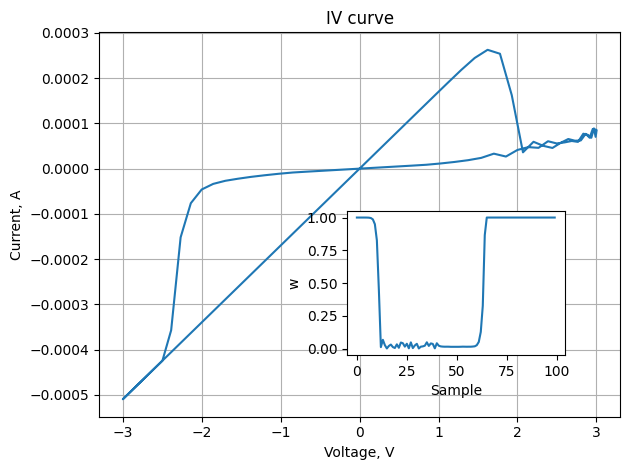

In [2]:
# memristor model
from simulator.memristor import MemristorModel
memristor = MemristorModel()

memristor.step = 10e-6 # simulation time step
signal = 3*np.sin(np.linspace(0,2*np.pi,100))

current = []
w_state = [] # state wariable

for voltage_value in signal:
    current.append(memristor.apply_voltage(voltage_value))
    w_state.append(memristor.state_variable)

plt.title('IV curve')
plt.plot(signal,current)
plt.xlabel('Voltage, V')
plt.ylabel('Current, А')
plt.tight_layout()
plt.grid(True)

plt.axes([0.55, 0.25, .34, .3])
plt.plot(w_state)
plt.xlabel('Sample')
plt.ylabel('w')

Text(0, 0.5, 'w')

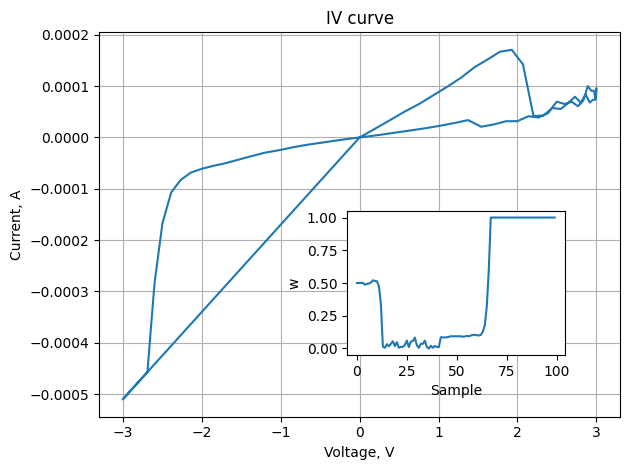

In [5]:
# crossbar model
from simulator.src import create_crossbar_array, load_crossbar_array, save_crossbar_array

serial = 'my_simulator'
row_num = 32
col_num = 8
create_crossbar_array(serial, row_num, col_num)
status, crossbar = load_crossbar_array(serial)

BL = 0
WL = 0

current = []
w_state = [] # state wariable

for voltage_value in signal:
    current.append(crossbar[BL][WL].apply_voltage(voltage_value))
    w_state.append(crossbar[BL][WL].state_variable)

save_crossbar_array(serial, crossbar)

plt.title('IV curve')
plt.plot(signal, current)
plt.xlabel('Voltage, V')
plt.ylabel('Current, А')
plt.tight_layout()
plt.grid(True)

plt.axes([0.55, 0.25, .34, .3])
plt.plot(w_state)
plt.xlabel('Sample')
plt.ylabel('w')

Our boards are multi-mode devices. We usually work with boards in the mode of applying rectangular pulses to the memristor - mode_7. The query syntax of mode_7 is as follows:
- v_dac - DAC data bits;
- tms - pulse duration ms;
- tus - pulse duration us (total is tms+tus);
- rev - 0 for applying to BL (forward), 1 for applying to Net (reverse);
- task_id - task id;
- wl - word line number;
- bl - bit line number.
We call it a single task. Usually we use 0.3 V for the read pulse and less than 2-2.5 V for write pulses.

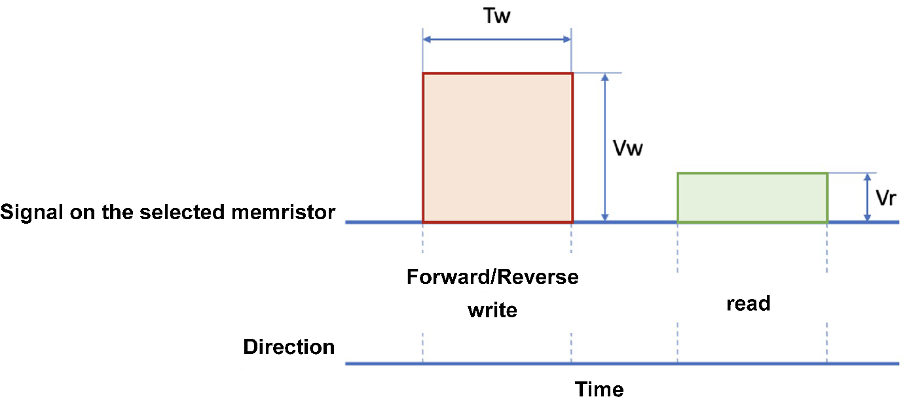

simulator_settings.ini существует в текущей папке


Text(0, 0.5, 'DOC')

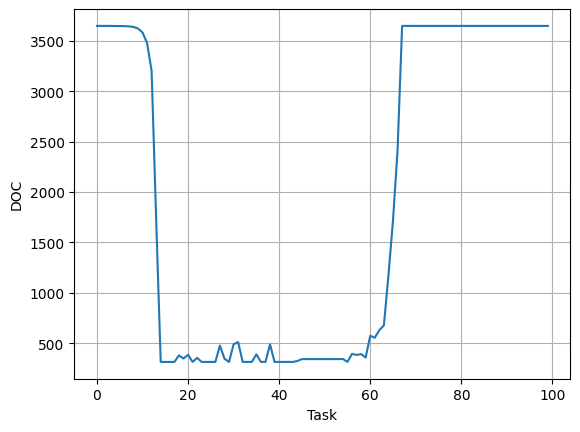

In [6]:
from simulator.src import BoardSimulator # connect to board. simulator

conn = BoardSimulator()
_ = conn.connect(serial)

v_dac_max = 2500

pulse_sequence_increase = [i for i in range(0,v_dac_max,100)]
pulse_sequence_decrease = [v_dac_max-100 - i for i in range(0,v_dac_max,100)]

results = []
all_v_dac = []
all_sign = []
rev = 0
# reset increase
for item, v_dac in enumerate(pulse_sequence_increase):
    res, task_id = conn.mode_7(v_dac, 0, 100, rev, item, BL, WL)
    results.append(res)
    all_v_dac.append(v_dac)
    all_sign.append(rev)
# reset decrease
for item, v_dac in enumerate(pulse_sequence_decrease):
    res, task_id = conn.mode_7(v_dac, 0, 100, rev, item, BL, WL)
    results.append(res)
    all_v_dac.append(v_dac)
    all_sign.append(rev)
rev = 1
# set increase
for item, v_dac in enumerate(pulse_sequence_increase):
    res, task_id = conn.mode_7(v_dac, 0, 100, rev, item, BL, WL)
    results.append(res)
    all_v_dac.append(v_dac)
    all_sign.append(rev)
# set decrease
for item, v_dac in enumerate(pulse_sequence_decrease):
    res, task_id = conn.mode_7(v_dac, 0, 100, rev, item, BL, WL)
    results.append(res)
    all_v_dac.append(v_dac)
    all_sign.append(rev)

plt.plot(results)
plt.grid(True)
plt.xlabel('Task')
plt.ylabel('DOC')


To convert DAC and ADC data bits, we have converters:
- d2v - DAC to voltage;
- v2d - voltage to DAC;
- a2r - ADC to resistance;
etc. (r2a, r2w, w2r, a2v, a2c)

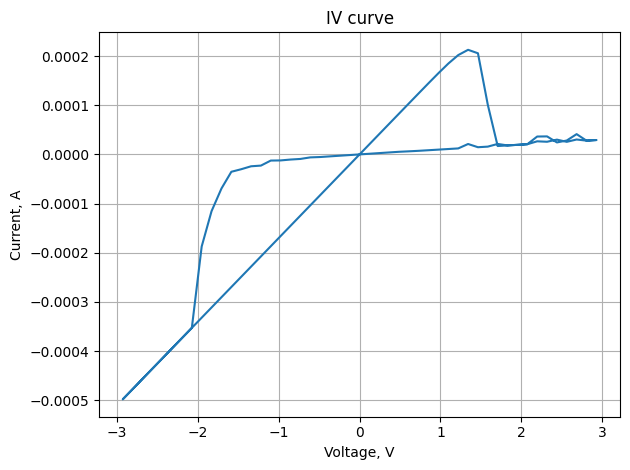

In [7]:
from manager.service import d2v, a2r

dac_bit = 12
vol_ref_dac = 5
res_load = 3000
vol_read = 0.3
adc_bit = 14
vol_ref_adc = 5
res_switches = 10
gain = 11.0
sum_gain = 330
read_time = 1200
blank_time = 5
blank_time_between = 55000
soft_cc = 0.002

voltages = np.array(list(map(lambda x, y: d2v(dac_bit, vol_ref_dac, x, sign=y), all_v_dac, all_sign)))
resistances = np.array(list(map(lambda x: a2r(gain, res_load, vol_read, adc_bit, vol_ref_adc, res_switches, x), results)))
currents = voltages/resistances

plt.title('IV curve')
plt.plot(voltages, currents)
plt.xlabel('Voltage, V')
plt.ylabel('Current, А')
plt.tight_layout()
plt.grid(True)

### GUI

Launch main.py for open MemriBoard GUI.
Read the documentation.

The first usage:
- create new crossbar account;
- choose the board;
- check settings;
- update resistance information (Ctrl+U)

#### Experiments with single cells

For experiments we need to create, load or import an experiment plan. The experiment plan consists of tickets. One ticket is a description of what signal sequence we want to apply to a memristor. It is a json-file stored in tickets folder.

In [ ]:
{"name": "blank",
 "mode": "std",
 "params": {"v_dir_strt_inc": 0,
            "v_dir_stop_inc": 0,
            "v_dir_step_inc": 0,
            "t_dir_msec_inc": 0,
            "t_dir_usec_inc": 0,
            "dir_inc_countr": 0,
            "v_dir_strt_dec": 0,
            "v_dir_stop_dec": 0,
            "v_dir_step_dec": 0,
            "t_dir_msec_dec": 0,
            "t_dir_usec_dec": 0,
            "dir_dec_countr": 0,
            "v_rev_strt_inc": 0,
            "v_rev_stop_inc": 0,
            "v_rev_step_inc": 0,
            "t_rev_msec_inc": 0,
            "t_rev_usec_inc": 0,
            "rev_inc_countr": 0,
            "v_rev_strt_dec": 0,
            "v_rev_stop_dec": 0,
            "v_rev_step_dec": 0,
            "t_rev_msec_dec": 0,
            "t_rev_usec_dec": 0,
            "rev_dec_countr": 0,
            "count": 0,
            "reverse": 0,
            "id": 0,
            "wl": 0,
            "bl": 0},
 "terminate": {"type": "pass",
               "value": 0}}

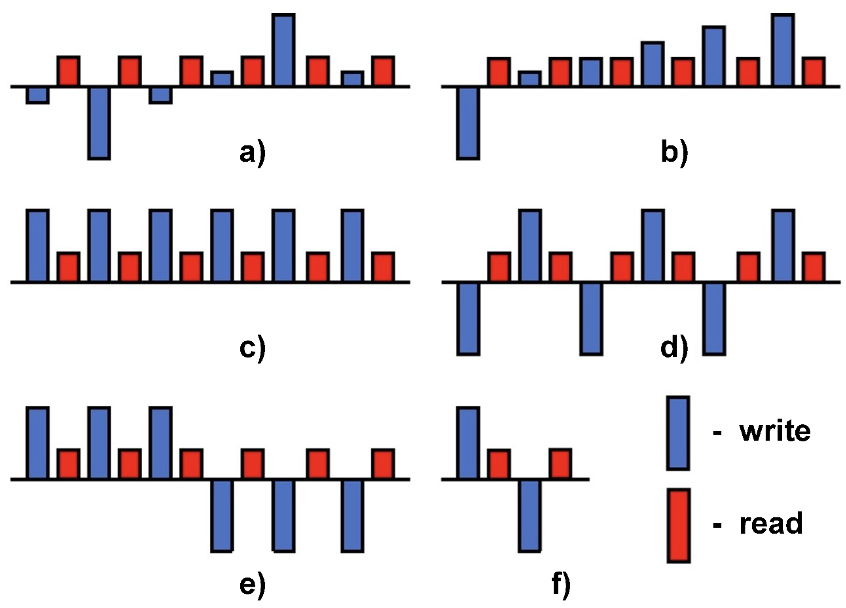

a) measuring the current-voltage characteristics;
b) writing the resistance;
c) assessing the stability of given resistive states as a function of voltage and readout time (retention);
d) assessing the stability of given resistive states as a function of the number of switching cycles (endurance);
e) measuring the synaptic plasticity characteristics;
f) switching a memristor into a HRS or LRS with a single pulse.


We can export the results of experiments to the disk in a csv file. We can repeat experiments from the history. We can export an experiment plan or tickets to the disk in a json file.